# Wave boundaries from spectra

**What this shows:** how to build XBeach wave boundaries from 2D wave spectra, such
as the site output of a regional wave model, in the three spectral file types XBeach
reads.

**Prerequisites:** [Tutorial 4: Adding forcing](../tutorial/04_forcing.ipynb).

**You will learn:**

- how spectra are selected at the model boundary from a set of sites
- the difference between JONSWAP (`parametric`), JONSWAP table (`jonstable`) and SWAN
  boundary files
- how to write a single boundary file or a time-varying file list
- the common settings that control how XBeach uses the boundary

**Data used:** `ww3-spectra-20230101-short.nc`, spectra every 3 hours at 19 sites of a
WAVEWATCH III model.

## Setup

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy_xbeach.grid import RegularGrid
from rompy_xbeach.source import SourceCRSWavespectra
from wavespectra import read_swan

logging_config.update(level="WARNING")  # rompy logs every step, show warnings only

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "waves_from_spectra"
shutil.rmtree(OUT_DIR, ignore_errors=True)

grid = RegularGrid(
    ori={"x": 115.594239, "y": -32.641104, "crs": 4326},
    alfa=347.0,
    dx=10.0,
    dy=15.0,
    nx=230,
    ny=220,
    crs=28350,
)
period = TimeRange(start="2023-01-01T00", end="2023-01-01T12", interval="1h")
source = SourceCRSWavespectra(
    uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
)
DIRECTIONS = {"thetamin": -90.0, "thetamax": 90.0, "dtheta": 10.0}


def generate(boundary, name):
    """Write a boundary to its own folder and print the XBeach parameters."""
    destdir = OUT_DIR / name
    destdir.mkdir(parents=True)
    params = boundary.get(destdir=destdir, grid=grid, time=period)
    for key, value in params.items():
        print(f"{key} = {value}")
    return destdir, params

## 1. Selecting spectra at the boundary

The `BoundaryStationSpectra...` classes pick spectra from a dataset of sites at the
middle of the offshore boundary (`location="offshore"`) or the grid centre. By
default they interpolate between the nearest sites by inverse distance weighting
(`sel_method="idw"`). `sel_method="nearest"` takes the closest site. Options such as
`tolerance` go in `sel_method_kwargs`.

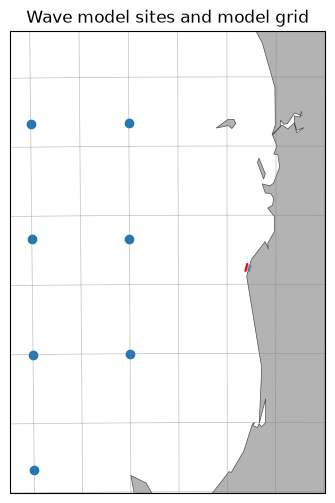

In [2]:
spectra = source.open()
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": grid.projection})
ax.scatter(
    spectra.lon, spectra.lat, c="tab:blue", transform=grid.transform.as_geodetic()
)
grid.plot(ax=ax, scale="i", set_extent=False, show_origin=False)
ax.set_extent([114.4, 116.0, -33.6, -31.6])
ax.set_title("Wave model sites and model grid")
plt.show()

## 2. JONSWAP parameters: `BoundaryStationSpectraJons`

The spectrum is reduced to JONSWAP parameters (Hm0, Tp, direction, peak enhancement
and spreading), and XBeach rebuilds a JONSWAP spectrum from them. By default a single
file describes the conditions at the start of the run.

In [3]:
from rompy_xbeach.data.boundary import BoundaryStationSpectraJons

destdir, params = generate(
    BoundaryStationSpectraJons(source=source, location="offshore", **DIRECTIONS),
    "jons_single",
)
print((destdir / params["bcfile"]).read_text())

wbctype = parametric
bcfile = parametric-20230101T000000.txt
thetamin = -90.0
thetamax = 90.0
dtheta = 10.0
dtbc = 1.0
mainang = 225.048
gammajsp = 1.49016
Tp = 14.4759
Hm0 = 2.95659
s = 7.79285



With `filelist=True` one file is written per source time step, and a file list tells
XBeach how long each one applies.

In [4]:
destdir, params = generate(
    BoundaryStationSpectraJons(
        source=source, location="offshore", filelist=True, **DIRECTIONS
    ),
    "jons_filelist",
)
print((destdir / params["bcfile"]).read_text())

wbctype = parametric
bcfile = parametric-filelist.txt
thetamin = -90.0
thetamax = 90.0
dtheta = 10.0
dtbc = 1.0
FILELIST
10800 1 parametric-20230101T000000.txt
10800 1 parametric-20230101T030000.txt
10800 1 parametric-20230101T060000.txt
10800 1 parametric-20230101T090000.txt



## 3. A table of JONSWAP parameters: `BoundaryStationSpectraJonstable`

All time steps go into one table. Each row holds Hm0, Tp, direction, gamma, spreading,
duration and time step.

In [5]:
from rompy_xbeach.data.boundary import BoundaryStationSpectraJonstable

destdir, params = generate(
    BoundaryStationSpectraJonstable(source=source, location="offshore", **DIRECTIONS),
    "jonstable",
)
print((destdir / params["bcfile"]).read_text())

wbctype = jonstable
bcfile = jonstable-20230101T000000-20230101T120000.txt
thetamin = -90.0
thetamax = 90.0
dtheta = 10.0
dtbc = 1.0
2.95659 14.4759 225.048 1.49016 7.79284 10800 1
2.99656 14.5061 225.328 1.60764 9.87488 10800 1
3.06017 14.3689 225.606 1.69296 11.3748 10800 1
3.30915 14.2411 225.912 1.39921 11.0055 10800 1
3.63085 14.1611 226.41 1.0517 8.5548 10800 1



## 4. Full spectra: `BoundaryStationSpectraSwan`

The spectrum is written as it is, in SWAN format, so XBeach sees the full frequency
and direction distribution, including multi-modal sea states that JONSWAP cannot
represent. `filelist=True` works the same way as for JONSWAP.

In [6]:
from rompy_xbeach.data.boundary import BoundaryStationSpectraSwan

destdir, params = generate(
    BoundaryStationSpectraSwan(
        source=source, location="offshore", filelist=True, **DIRECTIONS
    ),
    "swan_filelist",
)

wbctype = swan
bcfile = swan-filelist.txt
thetamin = -90.0
thetamax = 90.0
dtheta = 10.0
dtbc = 1.0


Reading the files back with wavespectra shows the swell evolving over the event:

Hs (m): [2.96 3.   3.06 3.31]


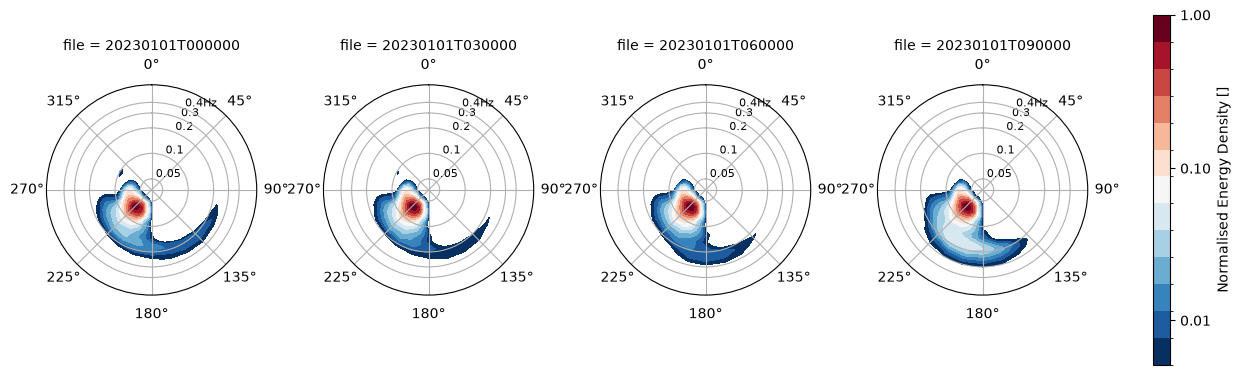

In [7]:
files = sorted(destdir.glob("swan-2023*.txt"))
spectra_written = xr.concat(
    [read_swan(file).squeeze(drop=True) for file in files],
    dim=pd.Index([file.stem[5:] for file in files], name="file"),
)
print("Hs (m):", spectra_written.spec.hs().round(2).values)
spectra_written.spec.plot(col="file", col_wrap=4, figsize=(14, 4))
plt.show()

## 5. Which spectral type to use?

| Type | Keeps | Good for |
|---|---|---|
| `parametric` | JONSWAP shape only | Single-peaked seas, simple setups |
| `jonstable` | JONSWAP shape, many times in one file | Long runs with slowly varying seas |
| `swan` | Full 2D spectrum | Mixed swell and sea, realistic directional spread |

## 6. Common wave boundary settings

These settings are available on every spectral boundary class and are written to
`params.txt` when set:

| Setting | Meaning |
|---|---|
| `thetamin`, `thetamax`, `dtheta` | Directional grid of the wave model (relative to the grid x-axis unless `thetanaut=True`) |
| `dtheta_s` | Directional resolution of the refraction solver when surfbeat runs in single-direction mode |
| `rt` | Duration of each generated boundary time series |
| `dtbc` | Time step of the generated boundary time series |
| `random` | Use a random seed for the wave phases (`False` makes runs repeatable) |
| `fcutoff` | Low-frequency cut-off of the spectrum |
| `taper` | Spin-up time of the boundary forcing |
| `order` | Second-order bound long waves (`2`) or short waves only (`1`) |

For example, a repeatable boundary with a 10-minute spin-up. Switches such as `random`
are written as `0` or `1` when the `Config` assembles `params.txt`.

In [8]:
boundary = BoundaryStationSpectraSwan(
    source=source, location="offshore", random=False, taper=600.0, **DIRECTIONS
)
destdir, params = generate(boundary, "swan_settings")

wbctype = swan
bcfile = swan-20230101T000000.txt
taper = 600.0
thetamin = -90.0
thetamax = 90.0
dtheta = 10.0
dtbc = 1.0
random = False


## Summary

- Spectra are selected at the offshore boundary by `idw` or `nearest`.
- Choose `parametric`, `jonstable` or `swan` depending on how much of the spectrum
  matters.
- `filelist=True` makes the boundary follow the source through time.

**See also:** [waves from parameters](waves_from_parameters.ipynb) when you only have
Hs, Tp and direction, and [existing files and reuse](waves_from_files_and_reuse.ipynb)
for boundary files made elsewhere.